IMPORTS

In [ ]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
import json
import numpy as np
from PIL import Image
import random
from torch.utils.data import Dataset
from PIL import Image
import numpy as np
import os
import torch
import torchvision.transforms as T
from torch.utils.data import DataLoader
import torchvision.models as models
import torch.nn as nn
import torch.optim as optim
import time
from tqdm import tqdm
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

FILES

In [2]:
DATASET_DIR = r'D:\Resources\College Stuff\NFT\Mini Project\mapillary-vistas'
IMG_DIR = os.path.join(DATASET_DIR, 'training/img')
MASK_DIR = os.path.join(DATASET_DIR, 'training/mask')
META_PATH = os.path.join(DATASET_DIR, 'meta.json')

META LIST

In [3]:
with open(META_PATH) as f:
    meta = json.load(f)

meta_list = [{"title": c["title"], "id": c["id"], "color": c["color"]} for c in meta["classes"]]
print(meta_list)

[{'title': 'bird', 'id': 6479238, 'color': '#A52A2A'}, {'title': 'ground animal', 'id': 6479239, 'color': '#00C000'}, {'title': 'ambiguous barrier', 'id': 6479240, 'color': '#FAAA1F'}, {'title': 'concrete block', 'id': 6479241, 'color': '#FAAA20'}, {'title': 'curb', 'id': 6479242, 'color': '#C4C4C4'}, {'title': 'fence', 'id': 6479243, 'color': '#BE9999'}, {'title': 'guard rail', 'id': 6479244, 'color': '#B4A5B4'}, {'title': 'barrier', 'id': 6479245, 'color': '#5A7896'}, {'title': 'road median', 'id': 6479246, 'color': '#FAAA21'}, {'title': 'road side', 'id': 6479247, 'color': '#FAAA22'}, {'title': 'lane separator', 'id': 6479248, 'color': '#808080'}, {'title': 'temporary barrier', 'id': 6479249, 'color': '#FAAA23'}, {'title': 'wall', 'id': 6479250, 'color': '#66669C'}, {'title': 'bike lane', 'id': 6479251, 'color': '#8040FF'}, {'title': 'crosswalk - plain', 'id': 6479252, 'color': '#8C8CC8'}, {'title': 'curb cut', 'id': 6479253, 'color': '#AAAAAA'}, {'title': 'driveway', 'id': 6479254,

COLOR TO ID

In [4]:
# Step 1️: Build ID remapping (sorted so it's consistent)
raw_ids = sorted([item["id"] for item in meta_list])  # Ensures stable compact IDs
id_to_compact = {raw_id: i for i, raw_id in enumerate(raw_ids)}

# Identify unlabeled id and its compact version
UNLABELED_ID = 6479361
unlabeled_compact_id = id_to_compact[UNLABELED_ID]

# Step 2️: Build color → compact ID mapping
def hex_to_rgb(hex_color):
    hex_color = hex_color.lstrip('#')
    return tuple(int(hex_color[i:i+2], 16) for i in (0, 2, 4))

color_to_id = {
    hex_to_rgb(item["color"]): id_to_compact[item["id"]]
    for item in meta_list
}

# Step 3️: Converter function (defaults to unlabeled)
def color_to_id_converter(color, color_to_id_mapping, default_id):
    """Converts an RGB color tuple to its corresponding compact class ID."""
    return color_to_id_mapping.get(color, default_id)

# Example test output
print("Number of classes:", len(meta_list))
print("Unlabeled compact ID:", unlabeled_compact_id)
print("Sample mappings (color → compact id):")
for k, v in list(color_to_id.items())[:5]:
    print(k, "→", v)


Number of classes: 124
Unlabeled compact ID: 123
Sample mappings (color → compact id):
(165, 42, 42) → 0
(0, 192, 0) → 1
(250, 170, 31) → 2
(250, 170, 32) → 3
(196, 196, 196) → 4


DATASET

In [5]:
class SegmentationDataset(Dataset):
    def __init__(self, img_dir, mask_dir, color_to_id_mapping, transform=None):
        self.img_dir = img_dir
        self.mask_dir = mask_dir
        self.color_to_id = color_to_id_mapping  # compact mapping
        self.transform = transform

        self.image_filenames = sorted([
            f for f in os.listdir(img_dir) if f.endswith('.jpg')
        ])

    def __len__(self):
        return len(self.image_filenames)

    def __getitem__(self, idx):
        img_filename = self.image_filenames[idx]
        img_path = os.path.join(self.img_dir, img_filename)
        mask_path = os.path.join(self.mask_dir, img_filename + '.png')

        # Load images
        image = Image.open(img_path).convert("RGB")
        mask = Image.open(mask_path).convert("RGB")

        # Resize if needed
        if self.transform:
            image = self.transform(image)
            mask = self.transform(mask)

        # Convert mask to numpy
        mask_array = np.array(mask)

        # Map RGB → compact IDs
        id_mask = np.zeros(mask_array.shape[:2], dtype=np.int64)
        for i in range(mask_array.shape[0]):
            for j in range(mask_array.shape[1]):
                pixel_color = tuple(mask_array[i, j])
                id_mask[i, j] = self.color_to_id.get(pixel_color, 123)  # default 123 if unknown

        # Convert to tensors
        image_tensor = T.ToTensor()(image)
        id_mask_tensor = torch.from_numpy(id_mask).long()

        return image_tensor, id_mask_tensor


DATA LOADERS

In [ ]:
# Define directories for training and validation data
TRAIN_IMG_DIR = os.path.join(DATASET_DIR, 'training/img')
TRAIN_MASK_DIR = os.path.join(DATASET_DIR, 'training/mask')
VAL_IMG_DIR = os.path.join(DATASET_DIR, 'validation/img')
VAL_MASK_DIR = os.path.join(DATASET_DIR, 'validation/mask')


transform = T.Resize((512, 512))  # resize only

# Create dataset instances for training and validation
train_dataset = SegmentationDataset(
    img_dir=TRAIN_IMG_DIR,
    mask_dir=TRAIN_MASK_DIR,
    color_to_id_mapping=color_to_id,
    transform=transform
)

val_dataset = SegmentationDataset(
    img_dir=VAL_IMG_DIR,
    mask_dir=VAL_MASK_DIR,
    color_to_id_mapping=color_to_id,
    transform=transform
)

batch_size = 4  # Adjust based on GPU memory

# Create DataLoaders
train_dataloader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0,
    pin_memory=False
)

val_dataloader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0,
    pin_memory=False
)

print(f"Number of samples in training dataset: {len(train_dataset)}")
print(f"Number of samples in validation dataset: {len(val_dataset)}")
print(f"Number of batches per training epoch: {len(train_dataloader)}")
print(f"Number of batches per validation epoch: {len(val_dataloader)}")

Number of samples in training dataset: 1067
Number of samples in validation dataset: 145
Number of batches per training epoch: 267
Number of batches per validation epoch: 37


MODEL

In [7]:
num_classes = len(meta_list)

# Load a pre-trained DeepLabV3 with ResNet50 (lighter than 101, safer for Colab)
# You can switch to resnet101 if you have GPU headroom
model = models.segmentation.deeplabv3_resnet50(weights="DEFAULT")

# Replace classifier for multi-class output
model.classifier[4] = nn.Conv2d(256, num_classes, kernel_size=1)

# Move model to device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("Current CUDA device:", torch.cuda.current_device())
    print("CUDA device name:", torch.cuda.get_device_name(torch.cuda.current_device()))
#device = torch.device("cpu")
model.to(device)

print(f"DeepLabV3 model ready with {num_classes} classes on {device}")

Using device: cuda
CUDA available: True
Current CUDA device: 0
CUDA device name: NVIDIA GeForce RTX 4070 Laptop GPU
DeepLabV3 model ready with 124 classes on cuda


In [8]:
images, masks = next(iter(train_dataloader))

print("Image shape:", images.shape)
print("Mask shape:", masks.shape)
print("Mask min:", masks.min().item())
print("Mask max:", masks.max().item())
print("Number of classes (num_classes):", num_classes)

Image shape: torch.Size([4, 3, 512, 512])
Mask shape: torch.Size([4, 512, 512])
Mask min: 4
Mask max: 123
Number of classes (num_classes): 124


In [9]:
unique_vals = torch.unique(masks)
print("Unique count:", len(unique_vals))
print("Sample values:", unique_vals[:50])
print("Max:", unique_vals.max().item())


Unique count: 48
Sample values: tensor([  4,   5,   6,  12,  16,  17,  18,  19,  21,  23,  24,  26,  27,  28,
         31,  32,  54,  58,  59,  61,  63,  64,  65,  66,  69,  72,  73,  74,
         78,  82,  83,  84,  86,  87,  88,  89,  95, 101, 102, 103, 105, 115,
        117, 119, 120, 121, 122, 123])
Max: 123


TRAINING

In [19]:
# Define loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

num_epochs = 10
train_losses, val_losses = [], []

print("Starting training...\n")

for epoch in range(num_epochs):
    start_time = time.time()
    model.train()
    running_train_loss = 0.0

    # Training loop
    for images, masks in tqdm(train_dataloader, desc=f"Epoch {epoch+1}/{num_epochs} [Train]"):
        images, masks = images.to(device), masks.to(device)

        optimizer.zero_grad()
        outputs = model(images)["out"]
        loss = criterion(outputs, masks)

        loss.backward()
        optimizer.step()

        running_train_loss += loss.item() * images.size(0)

    epoch_train_loss = running_train_loss / len(train_dataset)
    train_losses.append(epoch_train_loss)

    # Validation loop
    model.eval()
    running_val_loss = 0.0
    with torch.no_grad():
        for images, masks in tqdm(val_dataloader, desc=f"Epoch {epoch+1}/{num_epochs} [Val]"):
            images, masks = images.to(device), masks.to(device)
            outputs = model(images)["out"]
            loss = criterion(outputs, masks)
            running_val_loss += loss.item() * images.size(0)

    epoch_val_loss = running_val_loss / len(val_dataset)
    val_losses.append(epoch_val_loss)

    elapsed = time.time() - start_time
    print(f"Epoch [{epoch+1}/{num_epochs}] | "
          f"Train Loss: {epoch_train_loss:.4f} | "
          f"Val Loss: {epoch_val_loss:.4f} | "
          f"Time: {elapsed:.2f}s\n")

print("Training completed successfully!")

# Save model
SAVE_PATH = os.path.join(DATASET_DIR, "deeplabv3_resnet50_trained.pth")
torch.save(model.state_dict(), SAVE_PATH)
print(f"Model saved successfully to: {SAVE_PATH}")

Starting training...



Epoch 1/10 [Val]: 100%|██████████| 37/37 [01:58<00:00,  3.20s/it]


Epoch [1/10] | Train Loss: 1.9556 | Val Loss: 1.2647 | Time: 755.85s



Epoch 2/10 [Val]: 100%|██████████| 37/37 [00:56<00:00,  1.52s/it]


Epoch [2/10] | Train Loss: 1.1219 | Val Loss: 0.9850 | Time: 765.50s



...

Epoch [8/10] | Train Loss: 0.5398 | Val Loss: 0.8076 | Time: 535.62s



Epoch 9/10 [Val]: 100%|██████████| 37/37 [01:48<00:00,  2.94s/it]


Epoch [9/10] | Train Loss: 0.5083 | Val Loss: 0.6508 | Time: 983.70s



Epoch 10/10 [Val]: 100%|██████████| 37/37 [00:54<00:00,  1.48s/it]

Epoch [10/10] | Train Loss: 0.4669 | Val Loss: 0.6568 | Time: 773.89s

Training completed successfully!
Model saved successfully to: D:\Resources\College Stuff\NFT\Mini Project\mapillary-vistas\deeplabv3_resnet50_trained.pth


LOAD THE MODEL

In [10]:
# Make sure your model definition matches the saved weights
model.load_state_dict(torch.load(os.path.join(DATASET_DIR, "deeplabv3_resnet50_trained.pth"), map_location=device))
model.to(device)
model.eval()
print("Model loaded successfully!")

Model loaded successfully!


ID TO RGB MASK

In [11]:
# Build reverse mapping: compact_id → RGB color
compact_id_to_color = {v: k for k, v in color_to_id.items()}

def id_mask_to_rgb(id_mask, id_to_color_map):
    h, w = id_mask.shape
    rgb_img = np.zeros((h, w, 3), dtype=np.uint8)
    for compact_id, color in id_to_color_map.items():
        rgb_img[id_mask == compact_id] = color
    return rgb_img

# Example usage:
# output_mask = model_output.argmax(dim=1).cpu().numpy()[0]  # shape (H, W)
# rgb_image = id_mask_to_rgb(output_mask, compact_id_to_color)
# Image.fromarray(rgb_image).show()

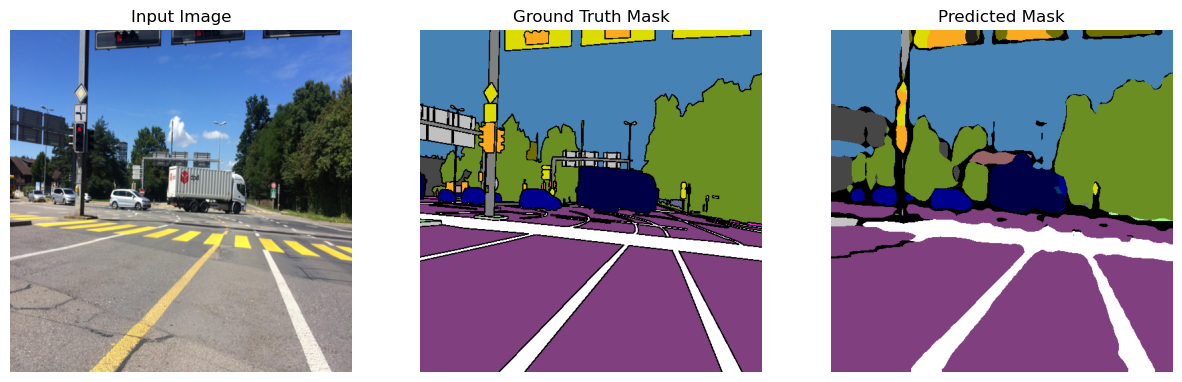

In [12]:
sample_filename = os.listdir(VAL_IMG_DIR)[0]  # Pick the first image (or specify one)

# Load image and mask
image_path = os.path.join(VAL_IMG_DIR, sample_filename)
mask_path = os.path.join(VAL_MASK_DIR, sample_filename + '.png')

image = Image.open(image_path).convert("RGB")
mask = Image.open(mask_path).convert("RGB")

# Resize if needed (match your model input size)
transform = T.Resize((512, 512))
image = transform(image)
mask = transform(mask)

# Convert image to tensor
image_tensor = T.ToTensor()(image).unsqueeze(0).to(device)  # Add batch dimension

# Convert mask to compact ID mask
mask_array = np.array(mask)
id_mask = np.zeros(mask_array.shape[:2], dtype=np.int64)
for i in range(mask_array.shape[0]):
    for j in range(mask_array.shape[1]):
        pixel_color = tuple(mask_array[i, j])
        id_mask[i, j] = color_to_id.get(pixel_color, 123)  # default 123 if unknown

# Run model prediction
model.eval()
with torch.no_grad():
    output = model(image_tensor)["out"]
    pred_mask = output.argmax(dim=1).cpu().numpy()[0]  # shape: (H, W)

# Convert masks to RGB
gt_mask_rgb = id_mask_to_rgb(id_mask, compact_id_to_color)
pred_mask_rgb = id_mask_to_rgb(pred_mask, compact_id_to_color)

# Plot
plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
plt.title("Input Image")
plt.imshow(image)
plt.axis('off')

plt.subplot(1,3,2)
plt.title("Ground Truth Mask")
plt.imshow(gt_mask_rgb)
plt.axis('off')

plt.subplot(1,3,3)
plt.title("Predicted Mask")
plt.imshow(pred_mask_rgb)
plt.axis('off')

plt.show()

GENERATING WALKABILTY JSON (DO NOT RUN)

In [ ]:
"""# Save the existing meta_list as JSON for manual editing
walkability_meta_path = os.path.join(DATASET_DIR, "walkability_meta.json")
with open(walkability_meta_path, "w") as f:
    json.dump(meta_list, f, indent=2)

print(f"Saved editable meta list to {walkability_meta_path}")

# Load the existing meta list
with open(os.path.join(DATASET_DIR, "walkability_meta.json"), "r") as f:
    walkability_meta_list = json.load(f)

# Add a blank walkability field to each entry
for entry in meta_list:
    entry["walkability"] = 0

# Save back to JSON
with open(os.path.join(DATASET_DIR, "walkability_meta.json"), "w") as f:
    json.dump(meta_list, f, indent=2)

print("Added blank walkability field to each entry in walkability_meta.json")"""

Saved editable meta list to D:\Resources\College Stuff\NFT\Mini Project\mapillary-vistas\walkability_meta.json
Added blank walkability field to each entry in walkability_meta.json


OUTPUT TO WALKABILITY

In [36]:
# Load walkability scores from JSON (id → walkability)
with open(os.path.join(DATASET_DIR, "walkability_meta.json"), "r") as f:
    walkability_meta = json.load(f)

# Build compact_id → walkability mapping using id_to_compact
compact_id_to_walkability = {}
for entry in walkability_meta:
    # If your walkability_meta has "id" and "walkability" fields
    raw_id = entry.get("id")
    score = entry.get("walkability", "")
    if raw_id is not None:
        compact_id = id_to_compact[raw_id]
        try:
            compact_id_to_walkability[compact_id] = float(score) if score != "" else 0.0
        except ValueError:
            compact_id_to_walkability[compact_id] = 0.0

print(compact_id_to_walkability)

{0: 0.0, 1: 0.0, 2: 0.0, 3: 0.0, 4: 1.0, 5: 0.0, 6: 0.0, 7: 0.0, 8: 0.0, 9: 1.0, 10: 0.0, 11: 0.0, 12: 0.0, 13: 0.0, 14: 1.0, 15: 1.0, 16: 0.0, 17: 0.0, 18: 0.0, 19: 1.0, 20: 0.0, 21: 1.0, 22: 0.0, 23: 0.0, 24: 1.0, 25: 1.0, 26: 0.0, 27: 0.0, 28: 0.0, 29: 0.0, 30: 0.0, 31: 0.0, 32: 0.0, 33: 0.0, 34: 0.0, 35: 0.0, 36: 0.0, 37: 0.0, 38: 0.0, 39: 0.0, 40: 0.0, 41: 0.0, 42: 0.0, 43: 0.0, 44: 0.0, 45: 0.0, 46: 0.0, 47: 0.0, 48: 0.0, 49: 0.0, 50: 0.0, 51: 0.0, 52: 0.0, 53: 0.0, 54: 0.0, 55: 0.0, 56: 0.0, 57: 0.0, 58: 0.0, 59: 0.0, 60: 0.0, 61: 0.0, 62: 0.0, 63: 1.0, 64: 0.0, 65: 0.0, 66: 0.0, 67: 0.0, 68: 0.0, 69: 0.0, 70: 0.0, 71: 0.0, 72: 0.0, 73: 0.0, 74: 0.0, 75: 0.0, 76: 0.0, 77: 0.0, 78: 0.0, 79: 0.0, 80: 0.0, 81: 0.0, 82: 0.0, 83: 0.0, 84: 0.0, 85: 0.0, 86: 0.0, 87: 0.0, 88: 0.0, 89: 0.0, 90: 0.0, 91: 0.0, 92: 0.0, 93: 0.0, 94: 0.0, 95: 0.0, 96: 0.0, 97: 0.0, 98: 0.0, 99: 0.0, 100: 0.0, 101: 0.0, 102: 0.0, 103: 0.0, 104: 0.0, 105: 0.0, 106: 0.0, 107: 0.0, 108: 0.0, 109: 0.0, 110: 0.0,

In [29]:
def compact_mask_to_walkability(mask, compact_id_to_walkability):
    
    h, w = mask.shape
    heatmap = np.zeros((h, w), dtype=np.float32)
    for compact_id, score in compact_id_to_walkability.items():
        heatmap[mask == compact_id] = score
    return heatmap

In [34]:
sample_filename = os.listdir(VAL_IMG_DIR)[51] 

# Load image
image_path = os.path.join(VAL_IMG_DIR, sample_filename)
image = Image.open(image_path).convert("RGB")

# Resize if needed (match your model input size)
transform = T.Resize((512, 512))
image = transform(image)

# Convert image to tensor
image_tensor = T.ToTensor()(image).unsqueeze(0).to(device)  # Add batch dimension

# Run model prediction
model.eval()
with torch.no_grad():
    output = model(image_tensor)["out"]
    pred_mask = output.argmax(dim=1).cpu().numpy()[0]  # shape: (H, W)

pred_mask_rgb = id_mask_to_rgb(pred_mask, compact_id_to_color)

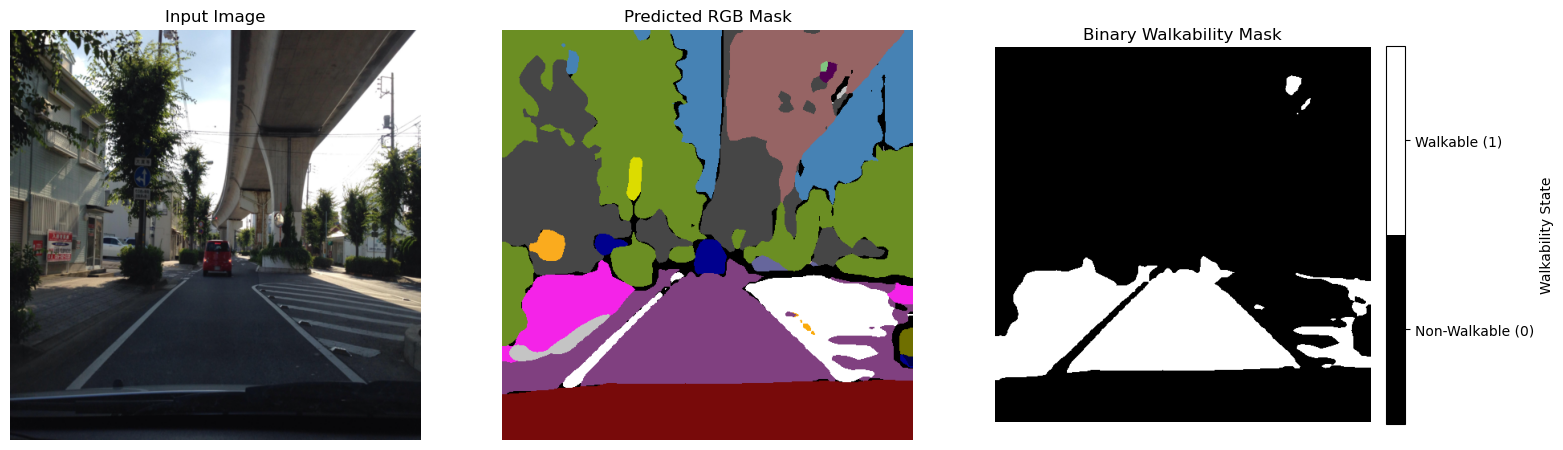

In [ ]:
walkability_heatmap = compact_mask_to_walkability(pred_mask, compact_id_to_walkability)

WALKABILITY_THRESHOLD = 0.5 
binary_walkable_mask = (walkability_heatmap > WALKABILITY_THRESHOLD).astype(float) 


cmap_binary = mcolors.ListedColormap(['black', 'white'])
norm_binary = mcolors.Normalize(vmin=0, vmax=1)

# --- Plotting Code ---
plt.figure(figsize=(18,6))
plt.subplot(1,3,1)
plt.title("Input Image")
plt.imshow(image)
plt.axis('off')

plt.subplot(1,3,2)
plt.title("Predicted RGB Mask")
plt.imshow(pred_mask_rgb)
plt.axis('off')

plt.subplot(1,3,3)
plt.title("Binary Walkability Mask")
# Use the new binary mask, colormap, and normalization
im = plt.imshow(binary_walkable_mask, cmap=cmap_binary, norm=norm_binary) 
plt.axis('off')

# Customizing the colorbar for a binary mask:
cbar = plt.colorbar(im, ticks=[0.25, 0.75], fraction=0.046, pad=0.04)
# Manually label the ticks for 0 and 1
cbar.ax.set_yticklabels(['Non-Walkable (0)', 'Walkable (1)'])
cbar.set_label("Walkability State")

plt.show()

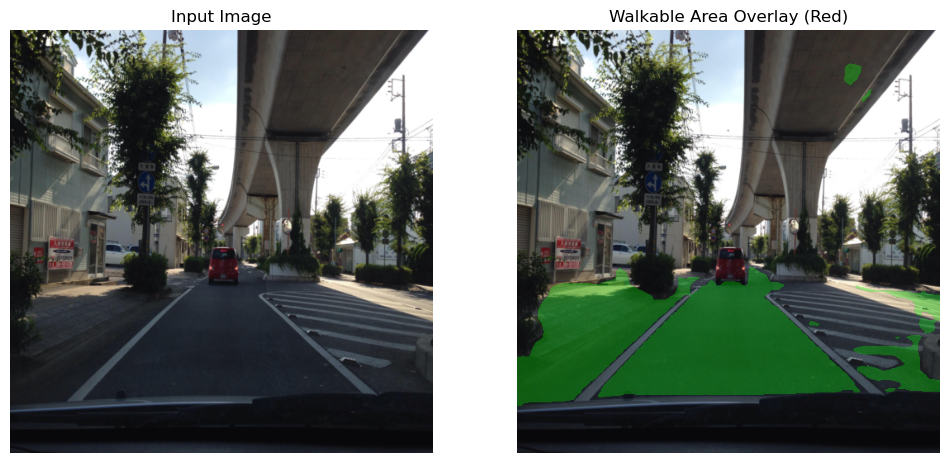

In [47]:
# --- 1. Create the Overlay Image ---
# Get the shape of the image (H, W, 3)
image_arr = np.array(image)
H, W, _ = image_arr.shape

# Initialize a transparent Red mask overlay (H, W, 4) - Red, Green, Blue, Alpha
# We'll use Red for "Walkable" areas.
overlay = np.zeros((H, W, 4))


# RGB fore green (0.0, 1.0, 0.0)
overlay_color = np.array([0.0, 1.0, 0.0]) 
transparency = 0.3 # 50% transparency

# Apply the red color and transparency ONLY where the mask is 1 (walkable)
# The binary_walkable_mask has shape (H, W). We need to tile it to (H, W, 3) for RGB and then add the alpha channel.

# Set RGB channels: Red only for walkable areas
overlay[..., :3] = overlay_color * binary_walkable_mask[..., np.newaxis] 

# Set Alpha channel: Apply transparency ONLY where the mask is 1
overlay[..., 3] = binary_walkable_mask * transparency 

# --- 2. Plotting the Overlay ---
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.title("Input Image")
plt.imshow(image)
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title("Walkable Area Overlay (Red)")
# Display the original image first
plt.imshow(image) 
# Then display the transparent overlay on top
plt.imshow(overlay) 
plt.axis('off')

plt.show()